# Contrastive Learning con pocas etiquetas
## ¿Puede SimCLR aprender representaciones útiles de MNIST sin conocer las clases?

**First Assignment — PRDL / MLLB**

> Presentación reproducible · Resultados cargados automáticamente · Sin cifras inventadas

<a class="presentation-qr" href="https://ml-eni.github.io/Contrastive-learning/" target="_blank" rel="noopener noreferrer" aria-label="Open the online presentation">
  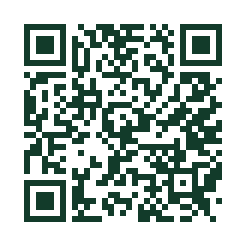
  <span>Escanea para abrir la demo</span>
</a>

In [1]:
from pathlib import Path
import json
import pandas as pd
from PIL import Image
from IPython.display import HTML, Markdown, display

ROOT = Path.cwd()
if not (ROOT / 'src').exists() and (ROOT.parent / 'src').exists():
    ROOT = ROOT.parent
assert (ROOT / 'src').exists(), 'Abre este notebook desde el repositorio.'
# Usa el experimento completo reducido cuando haya terminado; mientras tanto, conserva quick.
FULL_REDUCED = ROOT / 'outputs' / 'full_reduced'
manifest_path = FULL_REDUCED / 'run_manifest.json'
full_reduced_complete = False
if manifest_path.exists():
    manifest = json.loads(manifest_path.read_text())
    full_reduced_complete = manifest.get('status') == 'complete' and (FULL_REDUCED / 'metrics.csv').exists()
OUT = FULL_REDUCED if full_reduced_complete else ROOT / 'outputs' / 'quick'
PROFILE = 'full_reduced' if full_reduced_complete else 'quick'
FIG = OUT / 'figures'
metrics = pd.read_csv(OUT / 'metrics.csv')
display(HTML('''<style>
:root {
  --ink: #18251f; --muted: #5c6c63; --navy: #123b2a; --blue: #22664c;
  --cyan: #4f9f7a; --paper: #ffffff; --canvas: #edf3ef; --line: #d5e2da;
}
html { scroll-behavior: smooth; }
body.jp-Notebook {
  margin: 0; background: var(--canvas); color: var(--ink);
  font-family: Inter, ui-sans-serif, -apple-system, BlinkMacSystemFont, 'Segoe UI', sans-serif;
  font-size: 17px; line-height: 1.68;
}
body.jp-Notebook main {
  box-sizing: border-box; max-width: 1120px; margin: 36px auto; padding: 0 0 44px;
}
main > .jp-Cell {
  box-sizing: border-box; margin: 18px 0; padding: 32px 52px;
  background: var(--paper); border: 1px solid var(--line); border-radius: 16px;
  box-shadow: 0 8px 24px rgba(18, 59, 42, .06);
}
main > .jp-MarkdownCell[id='cell-id=title'] {
  position: relative; overflow: hidden; padding: 34px 190px 35px 42px;
  background: linear-gradient(135deg, #fbfdfb 0%, #edf6f0 100%);
  border: 1px solid #cbded2; border-left: 8px solid #2f7658;
  box-shadow: 0 12px 32px rgba(25, 75, 54, .10);
}
main > .jp-MarkdownCell[id='cell-id=title']::after { display: none; }
main > .jp-MarkdownCell[id='cell-id=title'] h1 {
  max-width: 950px; margin: 0 0 8px; color: #123b2a; border: 0;
  font-size: clamp(2rem, 3.3vw, 2.8rem); line-height: 1.06; letter-spacing: -.035em;
}
main > .jp-MarkdownCell[id='cell-id=title'] h2 {
  max-width: 900px; margin: 0 0 16px; color: #486557; font-size: clamp(1rem, 1.6vw, 1.22rem);
  line-height: 1.35; font-weight: 500;
}
main > .jp-MarkdownCell[id='cell-id=title'] p { margin: 8px 0; color: #4d6257; font-size: .92rem; }
main > .jp-MarkdownCell[id='cell-id=title'] p strong { color: #22664c; text-transform: uppercase; letter-spacing: .045em; }
main > .jp-MarkdownCell[id='cell-id=title'] blockquote {
  display: block; margin: 14px 0 0; padding: 12px 0 0; color: #597066; font-size: .82rem;
  background: transparent; border: 0; border-top: 1px solid #cddfd4; border-radius: 0;
}
main > .jp-MarkdownCell[id='cell-id=title'] blockquote p { margin: 0; }
.presentation-qr {
  position: absolute; right: 25px; bottom: 22px; width: 126px; padding: 8px 8px 7px;
  color: #285f49 !important; background: rgba(255,255,255,.88); border: 1px solid #c5d9cc;
  border-radius: 12px; box-shadow: 0 7px 18px rgba(18,59,42,.11); text-align: center; text-decoration: none !important;
}
.presentation-qr img { display: block; width: 92px; height: 92px; margin: 0 auto 5px; border: 0; border-radius: 5px; box-shadow: none; }
.presentation-qr span { display: block; color: #285f49; font-size: .65rem; font-weight: 750; line-height: 1.18; }
.presentation-qr:hover { border-color: #4f9f7a; transform: translateY(-1px); box-shadow: 0 9px 22px rgba(18,59,42,.15); }
.presentation-qr:focus-visible { outline: 3px solid #8bc5a8; outline-offset: 3px; }
.language-switcher {
  position: absolute; top: 22px; right: 24px; z-index: 5; display: flex; gap: 4px;
  padding: 4px; background: #e2eee6; border: 1px solid #c5d9cc; border-radius: 10px;
}
.language-switcher button {
  min-width: 42px; padding: 6px 10px; color: #466055; background: transparent;
  border: 0; border-radius: 7px; font: 700 .76rem/1 Inter, ui-sans-serif, sans-serif; cursor: pointer;
}
.language-switcher button.active { color: white; background: #22664c; box-shadow: 0 2px 7px rgba(18,59,42,.18); }
.language-switcher button:focus-visible { outline: 3px solid #8bc5a8; outline-offset: 2px; }
main > .jp-CodeCell[id='cell-id=setup'] { display: none; }
.jp-RenderedHTMLCommon h1 {
  margin: 0 0 24px; padding-bottom: 13px; color: var(--navy);
  border-bottom: 3px solid #dcebe2; font-size: 2rem; line-height: 1.2; letter-spacing: -.025em;
}
.jp-RenderedHTMLCommon h2 {
  margin: 30px 0 10px; color: var(--blue); font-size: 1.3rem; line-height: 1.3;
}
.jp-RenderedHTMLCommon h3 { color: var(--navy); }
.jp-RenderedHTMLCommon p, .jp-RenderedHTMLCommon li { color: var(--ink); }
.jp-RenderedHTMLCommon strong { color: #1d654a; }
.jp-RenderedHTMLCommon blockquote {
  margin: 24px 0; padding: 18px 22px; color: #194b37; background: #eef7f2;
  border: 0; border-left: 5px solid var(--cyan); border-radius: 0 10px 10px 0;
}
.jp-RenderedHTMLCommon blockquote p { margin: 0; color: inherit; }
.jp-RenderedHTMLCommon code {
  padding: .14em .42em; color: #285f49; background: #edf5f0; border-radius: 5px;
}
.jp-RenderedHTMLCommon pre, .jp-RenderedHTMLCommon .highlight {
  padding: 22px 26px; overflow-x: auto; color: #d9eee3; background: #123b2a;
  border-radius: 12px; box-shadow: inset 0 0 0 1px rgba(255,255,255,.06);
}
.jp-RenderedHTMLCommon pre code { padding: 0; color: inherit; background: transparent; }
.jp-RenderedHTMLCommon table {
  width: 100%; margin: 22px 0; border: 1px solid var(--line); border-collapse: separate;
  border-spacing: 0; border-radius: 11px; overflow: hidden; font-size: .96rem !important;
}
.jp-RenderedHTMLCommon thead th { padding: 13px 16px; color: white; background: var(--navy); border: 0; }
.jp-RenderedHTMLCommon tbody td, .jp-RenderedHTMLCommon tbody th { padding: 12px 16px; border-color: #e5edf3; }
.jp-RenderedHTMLCommon tbody tr:nth-child(even) { background: #f6f9fb; }
.jp-CodeCell .jp-Cell-outputWrapper,
.jp-CodeCell .jp-OutputArea,
.jp-CodeCell .jp-OutputArea-child,
.jp-CodeCell .jp-OutputArea-output,
.jp-CodeCell .jp-RenderedImage {
  box-sizing: border-box; width: 100% !important; max-width: 100% !important; min-width: 0 !important;
}
/* nbconvert uses table/table-cell for outputs. Safari keeps the image's intrinsic
   table width when this file is opened locally, producing a horizontal scrollbar. */
.jp-CodeCell .jp-OutputArea,
.jp-CodeCell .jp-OutputArea-child,
.jp-CodeCell .jp-OutputArea-output,
.jp-CodeCell .jp-RenderedImage {
  display: block !important; table-layout: auto !important; overflow: hidden !important;
}
.jp-CodeCell .jp-OutputPrompt { display: none !important; }
.jp-RenderedImage { text-align: center; }
.jp-RenderedImage img {
  display: block; width: 100% !important; max-width: 100% !important; height: auto !important;
  margin: 12px auto 4px; object-fit: contain;
  border: 1px solid #d7e4dc; border-radius: 12px; box-shadow: 0 10px 28px rgba(22, 68, 49, .10);
}
.jp-OutputArea { font-size: 1.02em; }
.anchor-link { opacity: 0; color: var(--cyan) !important; text-decoration: none !important; }
h1:hover .anchor-link, h2:hover .anchor-link { opacity: .55; }
@media (max-width: 760px) {
  body.jp-Notebook { font-size: 15px; }
  body.jp-Notebook main { margin: 0; }
  main > .jp-Cell { margin: 10px; padding: 24px 20px; border-radius: 12px; }
  main > .jp-MarkdownCell[id='cell-id=title'] { padding: 68px 24px 30px; }
  .presentation-qr { position: static; display: flex; align-items: center; gap: 12px; width: fit-content; margin-top: 18px; text-align: left; }
  .presentation-qr img { width: 72px; height: 72px; margin: 0; }
  .presentation-qr span { max-width: 95px; }
  .language-switcher { top: 14px; right: 14px; }
  .jp-RenderedHTMLCommon h1 { font-size: 1.65rem; }
  .jp-RenderedHTMLCommon table { display: block; overflow-x: auto; white-space: nowrap; }
}
</style><script src="language-toggle.js" defer></script>'''))

# 1. El problema

Etiquetar datos cuesta tiempo y dinero, pero conseguir imágenes sin etiquetar suele ser más fácil.

### Pregunta de investigación

> Si SimCLR observa muchas imágenes **sin usar sus etiquetas**, ¿necesitará después menos ejemplos etiquetados para reconocer los dígitos?

Comparamos tres disponibilidades de etiquetas: **1 %**, **10 %** y **100 %**.

# 2. Diseño experimental

```text
                 Todas las imágenes de entrenamiento
                              │
              ┌───────────────┴────────────────┐
              │                                │
       CNN supervisada                  SimCLR autosupervisado
       1 %, 10 %, 100 %                 sin etiquetas
              │                                │
              │                         encoder congelado
              │                                │
              └──────── mismo subconjunto etiquetado ────────┘
                              │
                     evaluación final en test
```

También usamos **Logistic Regression** como referencia sencilla y un **encoder aleatorio** como control.

# 3. Dataset: MNIST

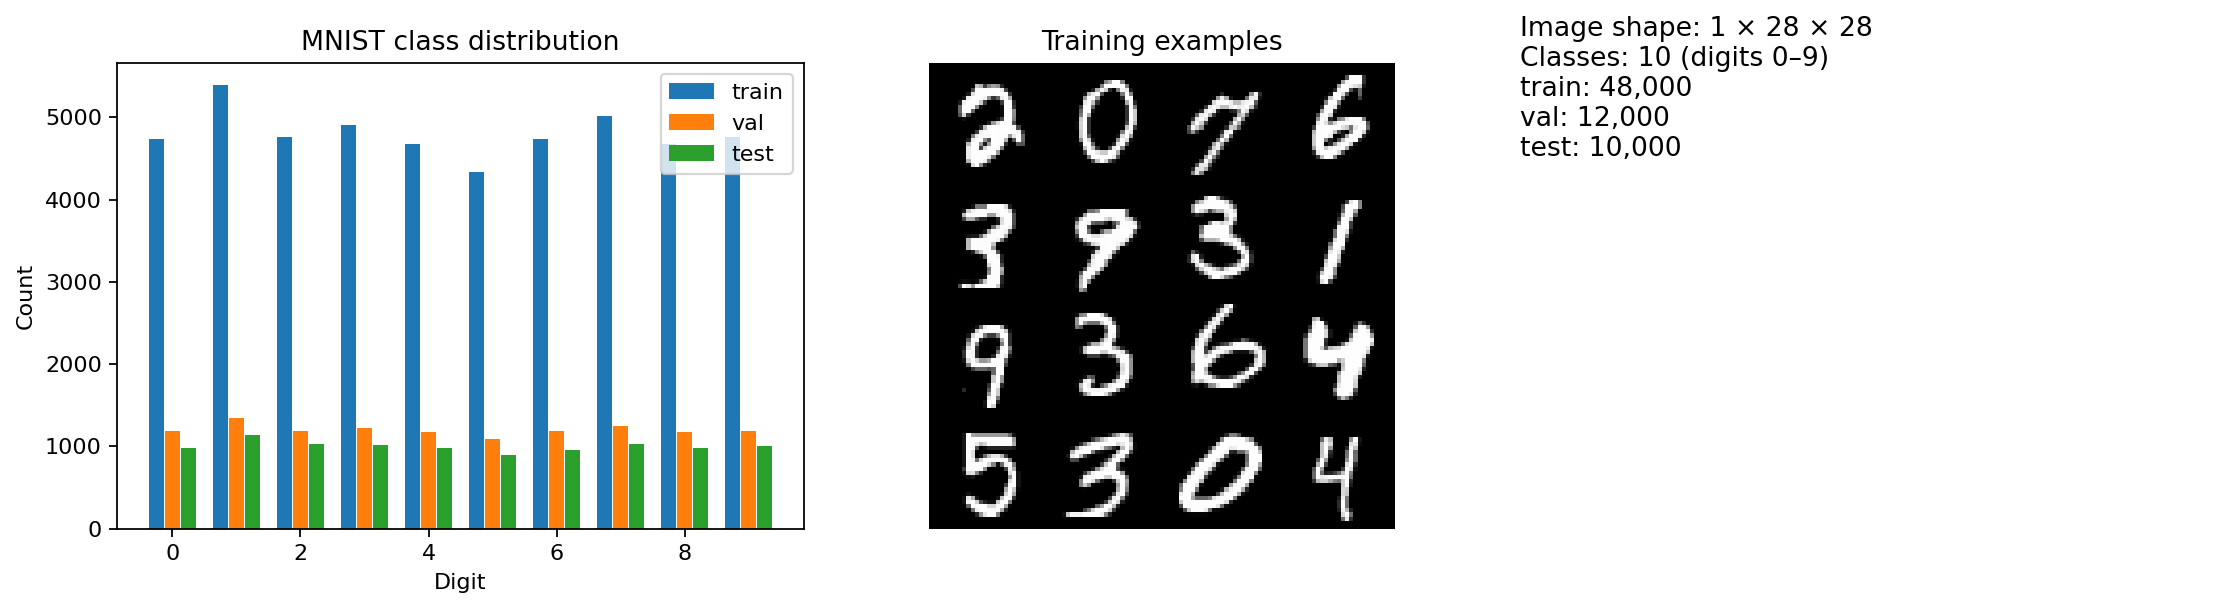

**Ejecución mostrada: `full_reduced`** — train: 48,000, validation: 12,000, test: 10,000. Semillas: [42]; épocas SimCLR/supervisado/probe: 8/10/10. Las particiones son estratificadas y no se solapan.

In [2]:
display(Markdown('# 3. Dataset: MNIST'))
display(Image.open(FIG / 'eda_mnist.png'))
cfg = json.loads((OUT / 'config.json').read_text())
display(Markdown(
    f"**Ejecución mostrada: `{PROFILE}`** — train: {cfg['train_size']:,}, "
    f"validation: {cfg['val_size']:,}, test: {cfg['test_size']:,}. "
    f"Semillas: {cfg['seeds']}; épocas SimCLR/supervisado/probe: "
    f"{cfg['contrastive_epochs']}/{cfg['supervised_epochs']}/{cfg['probe_epochs']}. "
    "Las particiones son estratificadas y no se solapan."
))

# 4. ¿Qué aprende SimCLR?

Para cada imagen generamos dos vistas moderadamente distintas:

- pequeñas rotaciones y traslaciones;
- cambios suaves de escala;
- ruido ligero;
- **sin flips**, porque podrían alterar el significado de un dígito.

Las dos vistas de la misma imagen forman un **par positivo**. Las demás vistas del batch son **negativos**.

$$\ell_{i,j}=-\log\frac{\exp(\operatorname{sim}(z_i,z_j)/\tau)}{\sum_{k\neq i}\exp(\operatorname{sim}(z_i,z_k)/\tau)}$$

NT-Xent aproxima los positivos y separa los negativos. Las etiquetas nunca entran en esta pérdida.

# 5. El control que aísla el efecto contrastivo

Comparamos dos encoders con **la misma arquitectura**:

| Control | Encoder | Clasificador | Etiquetas |
|---|---|---|---|
| Sin preentrenamiento | Pesos aleatorios y congelados | Lineal | 1 %, 10 %, 100 % |
| SimCLR | Preentrenado sin etiquetas y congelado | El mismo lineal | Los mismos IDs |

### Interpretación

> Si el linear probe de SimCLR supera al probe aleatorio, la mejora procede de la representación aprendida, no de un clasificador más potente.

In [3]:
display(Markdown('# 6. Resultados de clasificación'))
order = ['Supervised CNN', 'SimCLR linear probe', 'Random encoder probe', 'Logistic regression']
table = metrics.pivot(index='method', columns='label_fraction', values='accuracy').reindex(order)
table = (100 * table).rename(columns={0.01:'1 %', 0.1:'10 %', 1.0:'100 %'})
table.index = ['CNN supervisada', 'SimCLR + linear probe', 'Encoder aleatorio + probe', 'Regresión logística']
def semaphore(value):
    if value >= 80:
        return 'background-color: #cfe8d6; color: #174b2b; font-weight: 700'
    if value >= 60:
        return 'background-color: #fae9a9; color: #674f00; font-weight: 700'
    return 'background-color: #f4cfcc; color: #762c28; font-weight: 700'
display(table.style.format('{:.2f} %').map(semaphore))
display(Markdown('**Leyenda del semáforo:** 🟢 ≥ 80 % &nbsp;&nbsp; 🟡 60–79,99 % &nbsp;&nbsp; 🔴 < 60 %'))
if PROFILE == 'full_reduced':
    display(Markdown('> **Aviso:** se usa el dataset completo, pero con una sola semilla y calendario reducido (8/10/10 épocas) para limitar el coste de cómputo. No equivale al protocolo final de tres semillas y 30 épocas.'))
else:
    display(Markdown('> **Aviso:** `outputs/full_reduced` aún no está completo; se muestran resultados `quick`. Al terminar la ejecución reducida y volver a ejecutar este notebook, cambiará automáticamente a `full_reduced`.'))

# 6. Resultados de clasificación

label_fraction,1 %,10 %,100 %
CNN supervisada,87.33 %,92.34 %,98.66 %
SimCLR + linear probe,83.90 %,88.93 %,94.71 %
Encoder aleatorio + probe,28.54 %,25.19 %,34.40 %
Regresión logística,84.73 %,89.89 %,92.39 %


**Leyenda del semáforo:** 🟢 ≥ 80 % &nbsp;&nbsp; 🟡 60–79,99 % &nbsp;&nbsp; 🔴 < 60 %

> **Aviso:** se usa el dataset completo, pero con una sola semilla y calendario reducido (8/10/10 épocas) para limitar el coste de cómputo. No equivale al protocolo final de tres semillas y 30 épocas.

# 7. ¿Qué aportó realmente SimCLR?

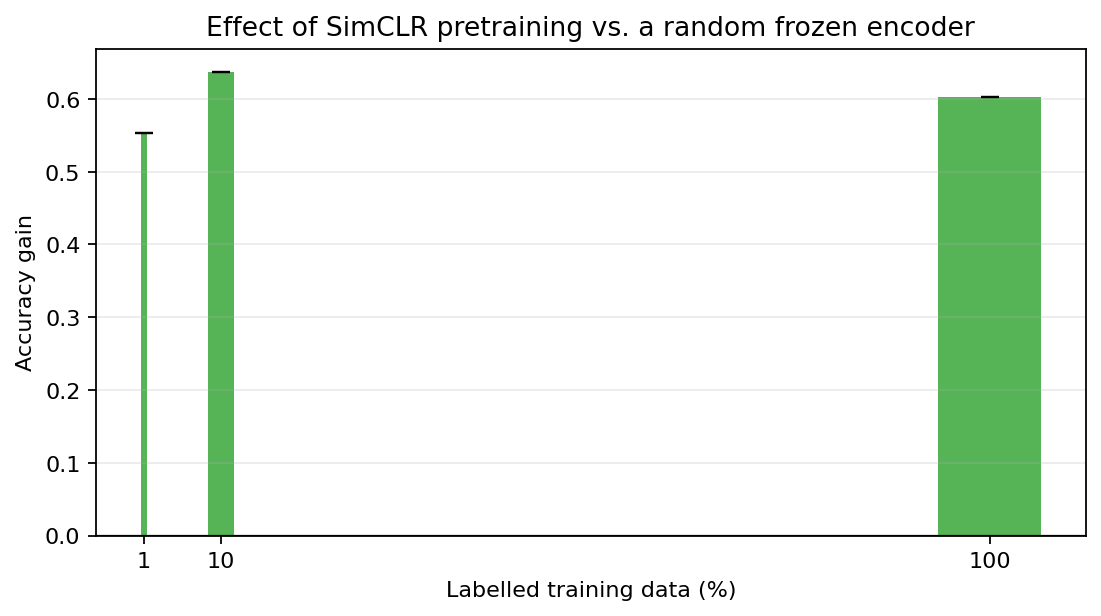

Ganancia del encoder preentrenado frente al aleatorio:  **1 %:** +55.4 puntos · **10 %:** +63.7 puntos · **100 %:** +60.3 puntos

In [4]:
display(Markdown('# 7. ¿Qué aportó realmente SimCLR?'))
display(Image.open(FIG / 'simclr_pretraining_gain.png'))
sim = metrics[metrics.method == 'SimCLR linear probe'].set_index('label_fraction').accuracy
rnd = metrics[metrics.method == 'Random encoder probe'].set_index('label_fraction').accuracy
gains = 100 * (sim - rnd)
parts = [f"**{int(frac*100)} %:** +{gain:.1f} puntos" for frac, gain in gains.items()]
display(Markdown('Ganancia del encoder preentrenado frente al aleatorio:  ' + ' · '.join(parts)))

# 8. Evidencia dentro del espacio de embeddings

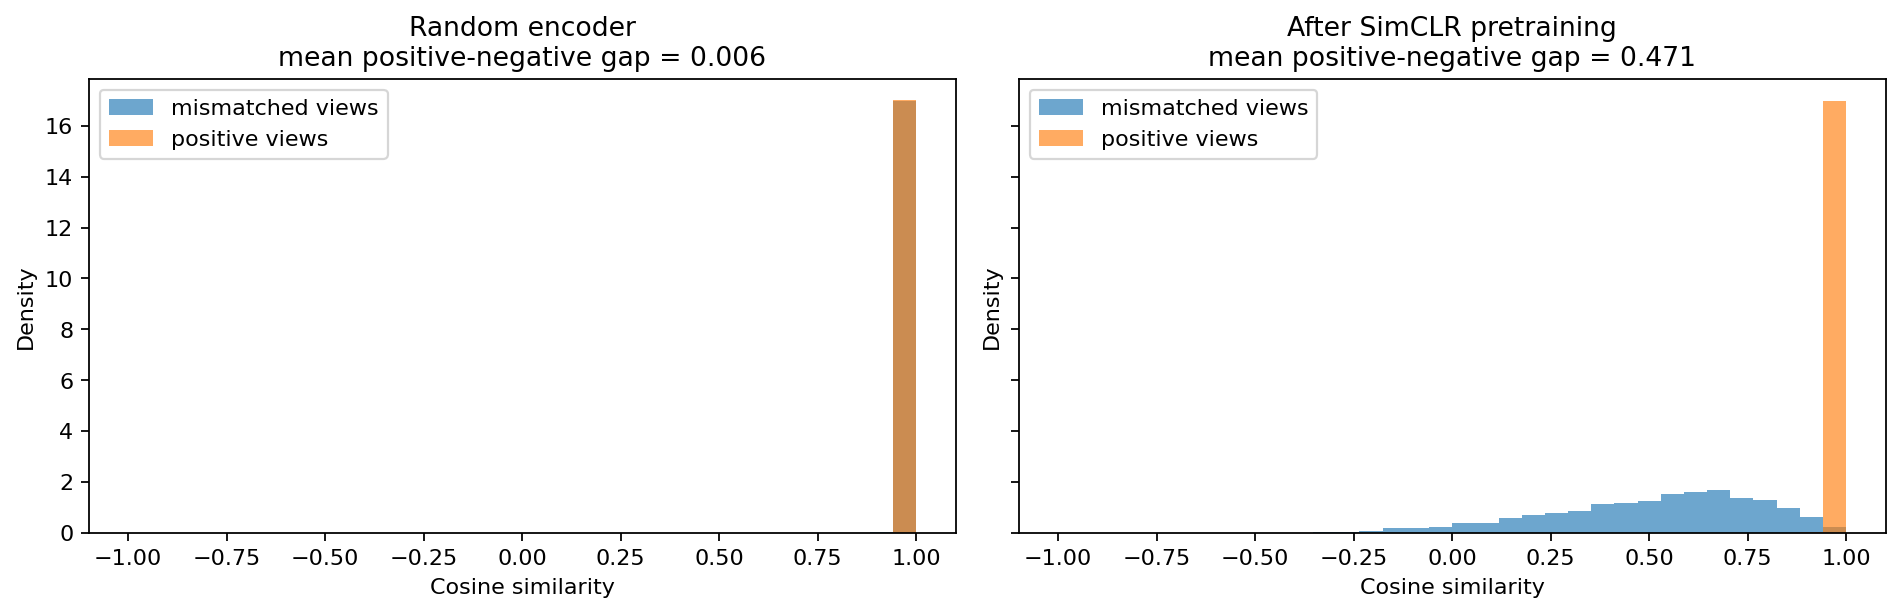

Separación media positivo–negativo: **0.006** antes y **0.471** después de SimCLR.

In [5]:
display(Markdown('# 8. Evidencia dentro del espacio de embeddings'))
display(Image.open(FIG / 'positive_negative_similarity.png'))
files = sorted(OUT.glob('similarity_seed_*.json'))
if files:
    diagnostics = [json.loads(p.read_text()) for p in files]
    random_gap = sum(d['random_gap'] for d in diagnostics) / len(diagnostics)
    pretrained_gap = sum(d['pretrained_gap'] for d in diagnostics) / len(diagnostics)
    display(Markdown(
        f"Separación media positivo–negativo: **{random_gap:.3f}** antes y "
        f"**{pretrained_gap:.3f}** después de SimCLR."
    ))

# 9. ¿Qué imágenes considera parecidas?

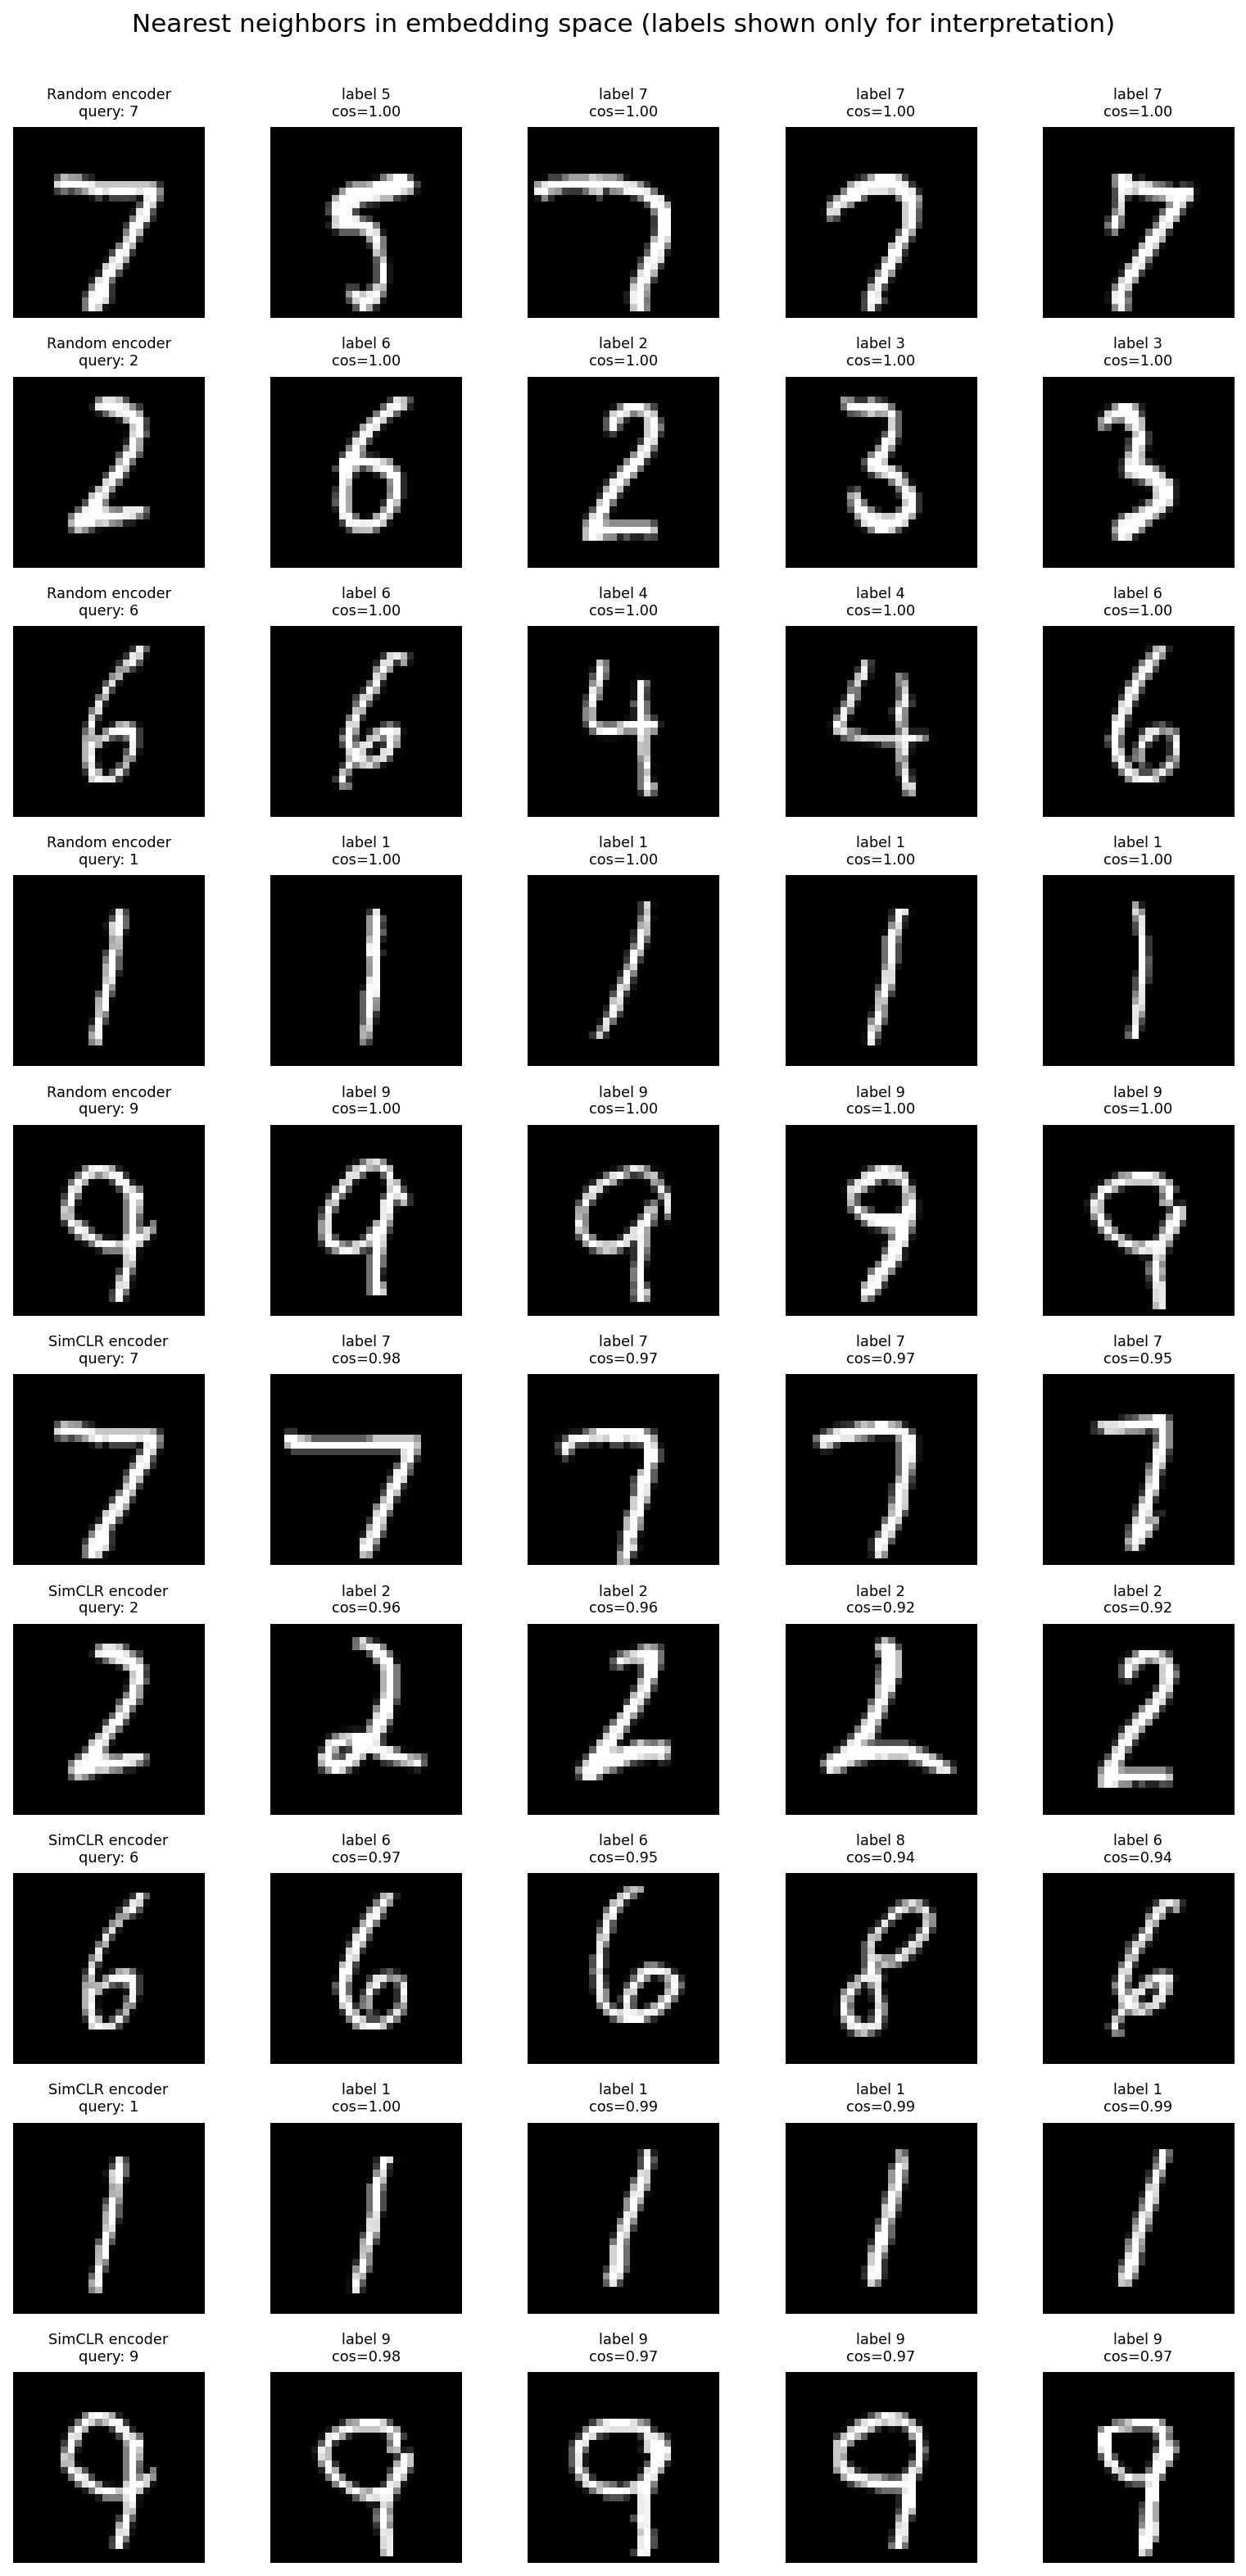

Los vecinos se buscan solo mediante los embeddings. Las clases se muestran después, exclusivamente para interpretar la representación.

In [6]:
display(Markdown('# 9. ¿Qué imágenes considera parecidas?'))
display(Image.open(FIG / 'embedding_nearest_neighbors.png'))
display(Markdown(
    'Los vecinos se buscan solo mediante los embeddings. Las clases se muestran después, '
    'exclusivamente para interpretar la representación.'
))

# 10. Comparación global

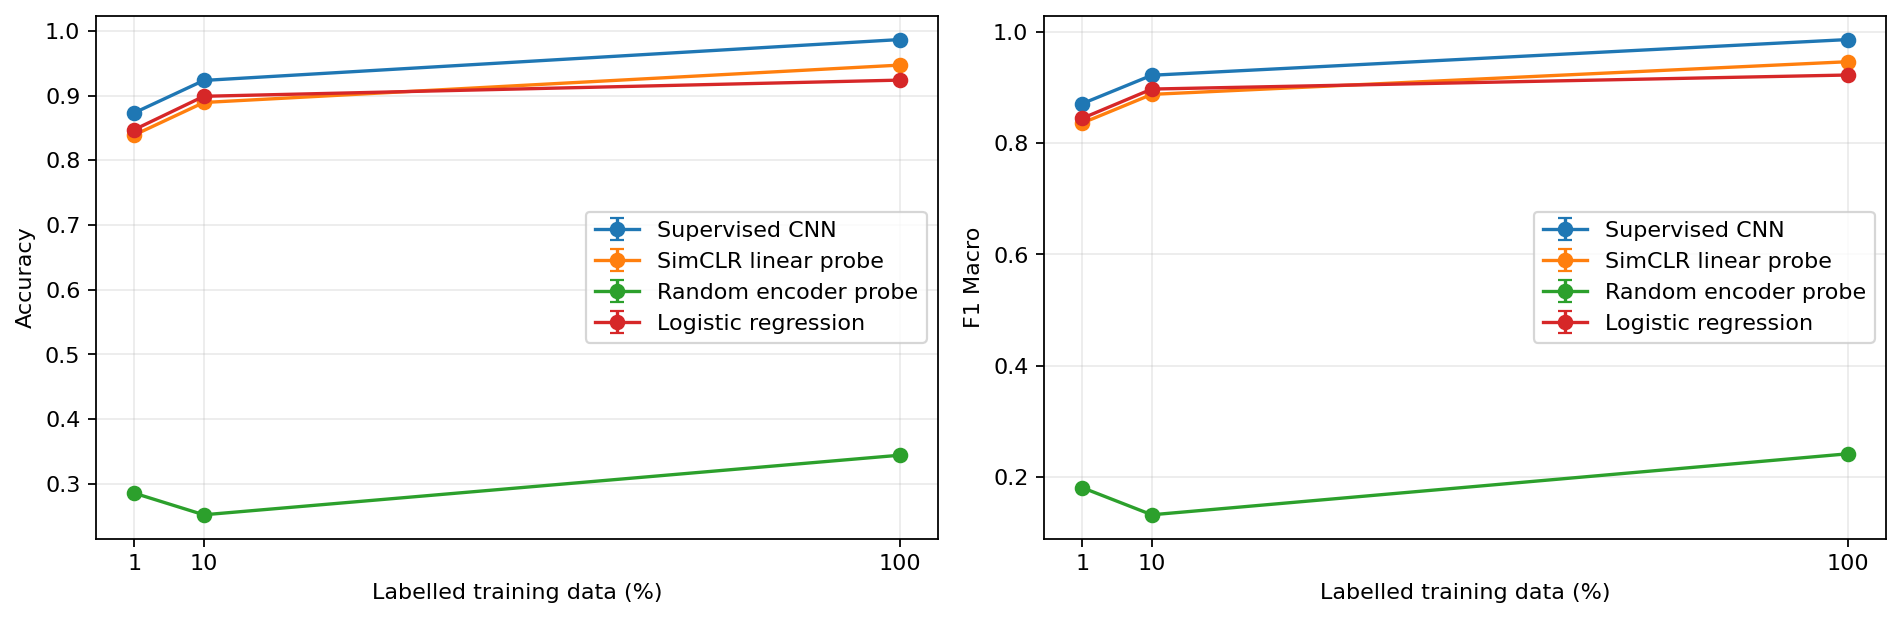

**Lectura correcta:** SimCLR debe compararse primero con el encoder aleatorio para medir la calidad aprendida. Compararlo con la CNN y Logistic Regression responde a una pregunta adicional: si esa representación produce el mejor clasificador final.

In [7]:
display(Markdown('# 10. Comparación global'))
display(Image.open(FIG / 'method_comparison.png'))
display(Markdown(
    '**Lectura correcta:** SimCLR debe compararse primero con el encoder aleatorio para medir '
    'la calidad aprendida. Compararlo con la CNN y Logistic Regression responde a una pregunta '
    'adicional: si esa representación produce el mejor clasificador final.'
))

# 11. Limitaciones

- MNIST es pequeño, centrado y mucho más sencillo que imágenes naturales.
- SimCLR es sensible al tamaño del batch y al número de épocas.
- El método contrastivo ve más imágenes sin etiquetar y consume más cómputo: no es una comparación de coste equivalente.
- El linear probe mide separabilidad lineal, no todo lo que podría obtenerse mediante fine-tuning.
- La ejecución mostrada usa una sola semilla; el protocolo final requiere tres semillas y 30 épocas por fase.
- `full_reduced` usa todos los datos, pero un calendario reducido de 8/10/10 épocas para limitar el coste de cómputo.
- Las etiquetas de test se utilizan una vez fijado el modelo, nunca para seleccionar hiperparámetros.

In [8]:
def accuracy_pct(method, fraction):
    row = metrics[(metrics.method == method) & (metrics.label_fraction == fraction)]
    return 100 * float(row.iloc[0].accuracy)

cnn_1 = accuracy_pct('Supervised CNN', 0.01)
cnn_10 = accuracy_pct('Supervised CNN', 0.10)
cnn_100 = accuracy_pct('Supervised CNN', 1.0)
simclr_1 = accuracy_pct('SimCLR linear probe', 0.01)
simclr_10 = accuracy_pct('SimCLR linear probe', 0.10)
simclr_100 = accuracy_pct('SimCLR linear probe', 1.0)
logistic_1 = accuracy_pct('Logistic regression', 0.01)
logistic_10 = accuracy_pct('Logistic regression', 0.10)
logistic_100 = accuracy_pct('Logistic regression', 1.0)
random_1 = accuracy_pct('Random encoder probe', 0.01)
random_10 = accuracy_pct('Random encoder probe', 0.10)
random_100 = accuracy_pct('Random encoder probe', 1.0)
mean_gain = float(gains.mean())  # `gains` ya está expresado en puntos porcentuales.
shown_seed = int(cfg['seeds'][0])
contrastive_history = pd.read_csv(OUT / f'histories/simclr_seed_{shown_seed}.csv')
loss_start = float(contrastive_history.iloc[0].train_loss)
loss_end = float(contrastive_history.iloc[-1].train_loss)
simclr_vs_cnn = {f: accuracy_pct('SimCLR linear probe', f) - accuracy_pct('Supervised CNN', f) for f in (0.01, 0.10, 1.0)}
simclr_vs_logistic = {f: accuracy_pct('SimCLR linear probe', f) - accuracy_pct('Logistic regression', f) for f in (0.01, 0.10, 1.0)}

display(Markdown(f'''# 12. Conclusiones e interpretación de los resultados

## El preentrenamiento contrastivo cambia claramente el resultado

Frente al mismo encoder aleatorio y congelado, SimCLR mejora **{gains.loc[0.01]:.2f}**, **{gains.loc[0.10]:.2f}** y **{gains.loc[1.0]:.2f} puntos** con 1 %, 10 % y 100 % de etiquetas. La ganancia media es **{mean_gain:.2f} puntos**. Además, la loss contrastiva baja de **{loss_start:.3f}** a **{loss_end:.3f}** y la separación coseno positivo–negativo aumenta de **{random_gap:.3f}** a **{pretrained_gap:.3f}**. Las tres medidas respaldan que SimCLR aprendió estructura útil y que la mejora no procede únicamente del clasificador lineal.

## Con pocas etiquetas, SimCLR ya es competitivo

Con solo 480 etiquetas (1 %), SimCLR alcanza **{simclr_1:.2f} %**, frente a **{random_1:.2f} %** sin preentrenamiento, **{logistic_1:.2f} %** de Logistic Regression y **{cnn_1:.2f} %** de la CNN supervisada. Con 10 % obtiene **{simclr_10:.2f} %**. Esto demuestra utilidad con pocas etiquetas en esta ejecución, aunque no superioridad: queda **{-simclr_vs_cnn[0.01]:.2f}** y **{-simclr_vs_cnn[0.10]:.2f} puntos** por debajo de la CNN en 1 % y 10 %.

## Con todas las etiquetas cambia el segundo puesto

Con 100 % de etiquetas, la CNN supervisada sigue siendo la mejor con **{cnn_100:.2f} %**. SimCLR llega a **{simclr_100:.2f} %**: supera a Logistic Regression en **{simclr_vs_logistic[1.0]:.2f} puntos**, pero queda **{-simclr_vs_cnn[1.0]:.2f} puntos** por debajo de la CNN. Por tanto, el encoder congelado es muy informativo, aunque el entrenamiento end-to-end todavía aprovecha mejor las etiquetas.

## La arquitectura también influye

El encoder termina con `AdaptiveAvgPool2d(1)`, que comprime la distribución espacial en un vector global. Logistic Regression conserva los 784 píxeles y sus posiciones. Esto puede favorecer al baseline lineal en MNIST, aunque la comparación principal SimCLR–aleatorio sigue siendo justa porque ambos utilizan exactamente el mismo encoder.

## Qué podemos concluir, y qué no

> En la ejecución `{PROFILE}`, SimCLR aprende sin etiquetas una representación fuertemente separable y alcanza **{simclr_1:.2f} %** usando solo el 1 % de las etiquetas. Esto respalda que el preentrenamiento contrastivo puede producir representaciones útiles con poca supervisión.

Sin embargo, la CNN supervisada obtiene la mayor accuracy en los tres presupuestos. No podemos afirmar que SimCLR sea el mejor método ni generalizar el resultado a otras semillas o datasets. Esta ejecución usa una sola semilla y un calendario reducido de **{cfg['contrastive_epochs']}/{cfg['supervised_epochs']}/{cfg['probe_epochs']} épocas**; el protocolo confirmatorio sigue requiriendo tres semillas.
'''))

# 12. Conclusiones e interpretación de los resultados

## El preentrenamiento contrastivo cambia claramente el resultado

Frente al mismo encoder aleatorio y congelado, SimCLR mejora **55.36**, **63.74** y **60.31 puntos** con 1 %, 10 % y 100 % de etiquetas. La ganancia media es **59.80 puntos**. Además, la loss contrastiva baja de **5.435** a **5.082** y la separación coseno positivo–negativo aumenta de **0.006** a **0.471**. Las tres medidas respaldan que SimCLR aprendió estructura útil y que la mejora no procede únicamente del clasificador lineal.

## Con pocas etiquetas, SimCLR ya es competitivo

Con solo 480 etiquetas (1 %), SimCLR alcanza **83.90 %**, frente a **28.54 %** sin preentrenamiento, **84.73 %** de Logistic Regression y **87.33 %** de la CNN supervisada. Con 10 % obtiene **88.93 %**. Esto demuestra utilidad con pocas etiquetas en esta ejecución, aunque no superioridad: queda **3.43** y **3.41 puntos** por debajo de la CNN en 1 % y 10 %.

## Con todas las etiquetas cambia el segundo puesto

Con 100 % de etiquetas, la CNN supervisada sigue siendo la mejor con **98.66 %**. SimCLR llega a **94.71 %**: supera a Logistic Regression en **2.32 puntos**, pero queda **3.95 puntos** por debajo de la CNN. Por tanto, el encoder congelado es muy informativo, aunque el entrenamiento end-to-end todavía aprovecha mejor las etiquetas.

## La arquitectura también influye

El encoder termina con `AdaptiveAvgPool2d(1)`, que comprime la distribución espacial en un vector global. Logistic Regression conserva los 784 píxeles y sus posiciones. Esto puede favorecer al baseline lineal en MNIST, aunque la comparación principal SimCLR–aleatorio sigue siendo justa porque ambos utilizan exactamente el mismo encoder.

## Qué podemos concluir, y qué no

> En la ejecución `full_reduced`, SimCLR aprende sin etiquetas una representación fuertemente separable y alcanza **83.90 %** usando solo el 1 % de las etiquetas. Esto respalda que el preentrenamiento contrastivo puede producir representaciones útiles con poca supervisión.

Sin embargo, la CNN supervisada obtiene la mayor accuracy en los tres presupuestos. No podemos afirmar que SimCLR sea el mejor método ni generalizar el resultado a otras semillas o datasets. Esta ejecución usa una sola semilla y un calendario reducido de **8/10/10 épocas**; el protocolo confirmatorio sigue requiriendo tres semillas.


# Gracias

## Preguntas

**Idea clave:** el éxito contrastivo se mide primero por cuánto mejora la representación frente al mismo encoder sin preentrenar, no por asumir que debe ganar siempre a todos los clasificadores.